Due to size constraints, trained model checkpoints are not included.
They can be accessed via: [https://drive.google.com/drive/folders/1-NOwTYwpSwL2WPtkGJZYMeLaT_Te7Lvj?usp=sharing]

# Imports

In [ ]:
from datasets import load_dataset
import json
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import TrainingArguments
from transformers import Trainer, EvalPrediction, TrainerState
from transformers import AutoConfig
from transformers import XLMRobertaForQuestionAnswering
import os, json, glob
import numpy as np
import matplotlib.pyplot as plt
import evaluate
import collections
import wandb
from transformers import AutoModelForQuestionAnswering
import pandas as pd

# Paths

In [ ]:
#Relevant Paths

PROJECT_DIR = "."

# OUTPUT_DIR = f"{PROJECT_DIR}/nli_model"
OUTPUT_DIR_NLI = f"{PROJECT_DIR}/en_nli_model"
OUTPUT_DIR_QA  = f"{PROJECT_DIR}/qa_model_baseline"
OUTPUT_DIR_NLI_to_QA = f"{PROJECT_DIR}/EnNli_to_RuQa_model"
OUTPUT_DIR_RU_NLI = f"{PROJECT_DIR}/ru_nli_model"
OUTPUT_DIR_RU_NLI_TO_QA = f"{PROJECT_DIR}/RuNli_to_RuQa_model"
OUTPUT_DIR_RuBERT_QA = f"{PROJECT_DIR}/RuBERT_QA_model"
OUTPUT_DIR_BOOLQA = f"{PROJECT_DIR}/xlm_boolqa_model"
OUTPUT_DIR_BOOLQA_baseline = f"{PROJECT_DIR}/xlm_boolqa_model/xlmr_en_boolqa_baseline"
OUTPUT_DIR_RU_NLI_TO_ENBOOLQA = f"{PROJECT_DIR}/xlm_boolqa_model/xlmr_ru_to_enboolqa"


PLOTS_DIR_XNLI_EN  = f"{PROJECT_DIR}/finetune_xnli_en"
PLOTS_DIR_QA = f"{PROJECT_DIR}/qa_model"
PLOTS_DIR_NLI_to_QA = f"{PROJECT_DIR}/nli_transfer_to_qa_model"

os.makedirs(OUTPUT_DIR_NLI, exist_ok=True)
os.makedirs(OUTPUT_DIR_QA, exist_ok=True)
os.makedirs(PLOTS_DIR_XNLI_EN, exist_ok=True)
os.makedirs(OUTPUT_DIR_NLI_to_QA, exist_ok=True)
os.makedirs(OUTPUT_DIR_RU_NLI, exist_ok=True)
os.makedirs(OUTPUT_DIR_RU_NLI_TO_QA, exist_ok=True)
os.makedirs(OUTPUT_DIR_RuBERT_QA, exist_ok=True)
os.makedirs(OUTPUT_DIR_BOOLQA, exist_ok=True)
os.makedirs(OUTPUT_DIR_BOOLQA_baseline, exist_ok=True)
os.makedirs(OUTPUT_DIR_RU_NLI_TO_ENBOOLQA, exist_ok=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Loading and Inspecting Datasets

In [ ]:
# English NLI
xnli_en = load_dataset("xnli", "en")

# Russian NLI
xnli_ru = load_dataset("xnli", "ru")

# Russian Extractive QA
qa = load_dataset("sberquad")
xnli_en["train"][:2]

# English General QA
boolq_en = load_dataset("google/boolq")

print(xnli_en["train"][0])
print(xnli_ru["train"][0])
print(qa["train"][0])

README.md: 0.00B [00:00, ?B/s]

en/train-00000-of-00001.parquet:   0%|          | 0.00/50.2M [00:00<?, ?B/s]

en/test-00000-of-00001.parquet:   0%|          | 0.00/308k [00:00<?, ?B/s]

en/validation-00000-of-00001.parquet:   0%|          | 0.00/157k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/392702 [00:00<?, ? examples/s]

...

sberquad/test-00000-of-00001.parquet:   0%|          | 0.00/4.93M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45328 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5036 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/23936 [00:00<?, ? examples/s]

{'premise': 'Conceptually cream skimming has two basic dimensions - product and geography .', 'hypothesis': 'Product and geography are what make cream skimming work .', 'label': 1}
{'premise': 'Концептуально крем крем имеет два основных измерения - продукт и география .', 'hypothesis': 'Продукт и география - это то , что делает крем для работы с кремом .', 'label': 1}
{'id': 62310, 'title': 'SberChallenge', 'context': 'В протерозойских отложениях органические остатки встречаются намного чаще, чем в архейских. Они представлены известковыми выделениями сине-зелёных водорослей, ходами червей, остатками кишечнополостных. Кроме известковых водорослей, к числу древнейших растительных остатков относятся скопления графито-углистого вещества, образовавшегося в результате разложения Corycium enigmaticum. В кремнистых сланцах железорудной формации Канады найдены нитевидные водоросли, грибные нити и формы, близкие современным кокколитофоридам. В железистых кварцитах Северной Америки и Сибири обнар

## DataSet Structure (for better understanding)

In [ ]:
# Comments

# XNLI labels
# 0	entailment
# 1	neutral
# 2	contradiction

# XNLI dataset structure
# DatasetDict({
#     train: Dataset({
#         features: ['premise', 'hypothesis', 'label'],
#         num_rows: 392702
#     })
#     test: Dataset({
#         features: ['premise', 'hypothesis', 'label'],
#         num_rows: 5010
#     })
#     validation: Dataset({
#         features: ['premise', 'hypothesis', 'label'],
#         num_rows: 2490
#     })
# })

# xnli_en["train"][:2]
# {'premise': ['Conceptually cream skimming has two basic dimensions - product and geography .',
#   'you know during the season and i guess at at your level uh you lose them to the next level if if they decide to recall the the parent team the Braves decide to call to recall a guy from triple A then a double A guy goes up to replace him and a single A guy goes up to replace him'],
#  'hypothesis': ['Product and geography are what make cream skimming work .',
#   'You lose the things to the following level if the people recall .'],
#  'label': [1, 0]}


## Preprocessing Data for XNLI_ru & XNLI_en

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

def tokenize_nli(row):
  return tokenizer(
      row["premise"],
      row["hypothesis"],
      truncation=True,
      padding="max_length",
      max_length=128
  )

xnli_ru_tok = xnli_ru.map(tokenize_nli, batched=True)
xnli_en_tok = xnli_en.map(tokenize_nli, batched=True)

xnli_en_tok.set_format("torch")

xnli_ru_tok.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)



Map:   0%|          | 0/392702 [00:00<?, ? examples/s]

Map:   0%|          | 0/5010 [00:00<?, ? examples/s]

Map:   0%|          | 0/2490 [00:00<?, ? examples/s]

Map:   0%|          | 0/392702 [00:00<?, ? examples/s]

Map:   0%|          | 0/5010 [00:00<?, ? examples/s]

Map:   0%|          | 0/2490 [00:00<?, ? examples/s]

In [ ]:
# Rename label column to match model input format
xnli_ru_tok = xnli_ru_tok.rename_column("label", "labels")
print(xnli_ru_tok["train"].column_names)

['premise', 'hypothesis', 'labels', 'input_ids', 'attention_mask']


## Tokenizing Extractive RU QA Dataset: (train and validation)

In [ ]:
# Here I convert the raw QA data into token-level inputs that the model can actually learn from.
# Since the model predicts start and end tokens (not characters), I map the answer spans
# from character positions to token positions. I also handle truncation, so if the answer
# gets cut off, I default to (0,0). For evaluation, I keep extra info to map predictions back.

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base", use_fast=True)

MAX_LEN = 384

def tokenize_qa_train(batch):
    tokenized = tokenizer(
        batch["question"],
        batch["context"],
        truncation="only_second",
        padding="max_length",
        max_length=MAX_LEN,
        return_offsets_mapping=True
    )

    start_positions = []
    end_positions = []

    for i, offsets in enumerate(tokenized["offset_mapping"]):
        # SQuAD-format: answers["answer_start"] and answers["text"] are lists
        answer = batch["answers"][i]

        # If no answer (just in case)
        if len(answer["answer_start"]) == 0:
            start_positions.append(0)
            end_positions.append(0)
            continue

        start_char = answer["answer_start"][0]
        end_char = start_char + len(answer["text"][0])

        sequence_ids = tokenized.sequence_ids(i)

        # finding context span tokens (sequence id == 1)
        context_start = sequence_ids.index(1)
        context_end = len(sequence_ids) - 1 - sequence_ids[::-1].index(1)

        # default to [CLS] if not found
        start_token = 0
        end_token = 0

        # If answer is outside this window, we keep (0,0)
        if not (offsets[context_start][0] <= start_char and offsets[context_end][1] >= end_char):
            start_positions.append(0)
            end_positions.append(0)
            continue

        for idx in range(context_start, context_end + 1):
            if offsets[idx][0] <= start_char < offsets[idx][1]:
                start_token = idx
            if offsets[idx][0] < end_char <= offsets[idx][1]:
                end_token = idx
                break

        start_positions.append(start_token)
        end_positions.append(end_token)

    tokenized["start_positions"] = start_positions
    tokenized["end_positions"] = end_positions

    # train doesn't need offsets
    tokenized.pop("offset_mapping")
    return tokenized


def tokenize_qa_eval(batch):
    tokenized = tokenizer(
        batch["question"],
        batch["context"],
        truncation="only_second",
        padding="max_length",
        max_length=MAX_LEN,
        return_offsets_mapping=True
    )

    # we need to map feature -> original example
    tokenized["example_id"] = batch["id"]

    start_positions = []
    end_positions = []

    for i, offsets in enumerate(tokenized["offset_mapping"]):
        answer = batch["answers"][i]

        if len(answer["answer_start"]) == 0:
            start_positions.append(0)
            end_positions.append(0)
            continue

        start_char = answer["answer_start"][0]
        end_char = start_char + len(answer["text"][0])

        sequence_ids = tokenized.sequence_ids(i)

        # context span tokens (sequence id == 1)
        context_start = sequence_ids.index(1)
        context_end = len(sequence_ids) - 1 - sequence_ids[::-1].index(1)

        start_token = 0
        end_token = 0

        # answer outside this window
        if not (offsets[context_start][0] <= start_char and offsets[context_end][1] >= end_char):
            start_positions.append(0)
            end_positions.append(0)
            continue

        for idx in range(context_start, context_end + 1):
            if offsets[idx][0] <= start_char < offsets[idx][1]:
                start_token = idx
            if offsets[idx][0] < end_char <= offsets[idx][1]:
                end_token = idx
                break

        start_positions.append(start_token)
        end_positions.append(end_token)

    tokenized["start_positions"] = start_positions
    tokenized["end_positions"] = end_positions

    # masking offsets as we only allow context tokens (keep None here)
    new_offsets = []
    for i, offsets in enumerate(tokenized["offset_mapping"]):
        seq_ids = tokenized.sequence_ids(i)
        new_offsets.append([o if s == 1 else None for o, s in zip(offsets, seq_ids)])
    tokenized["offset_mapping"] = new_offsets

    return tokenized


qa_train = qa["train"].map(tokenize_qa_train, batched=True, remove_columns=qa["train"].column_names)
qa_val_features = qa["validation"].map(tokenize_qa_eval, batched=True, remove_columns=qa["validation"].column_names)

Map:   0%|          | 0/45328 [00:00<?, ? examples/s]

Map:   0%|          | 0/5036 [00:00<?, ? examples/s]

# First Step: Creating Baseline. XLM-R finetuned only on Russian Extractive QA (SberQuad)

## Model Initialization

In [ ]:
model = XLMRobertaForQuestionAnswering.from_pretrained("xlm-roberta-base")

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForQuestionAnswering LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
qa_outputs.bias             | MISSING    | 
qa_outputs.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Training

###Defining Training Arguments

In [ ]:
# Here I use logging steps instead of epochs to get more fine-grained tracking
# and more detailed logs both in W&B and locally.

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR_QA,

    eval_strategy="steps",
    eval_steps=500,

    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,

    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_strategy="steps",
    logging_steps=50,

    remove_unused_columns=True,
    report_to="wandb",
)

# This is debugging code I used to make sure everything works.
# Initially, I had an error because of a column name mismatch:
# the model expected "labels" instead of "label".

# training_args = TrainingArguments(
#     output_dir=OUTPUT_DIR_QA,

#     eval_strategy="steps",

#     eval_steps=5,
#     save_strategy="no",

#     max_steps=10,

#     learning_rate=3e-5,
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,
#     # num_train_epochs=2,

#     weight_decay=0.01,

#     load_best_model_at_end=False,
#     # metric_for_best_model="f1",
#     # greater_is_better=True,

#     logging_strategy="steps",
#     logging_steps=5,

#     remove_unused_columns=True,
#     report_to="wandb",
# )

### Postprocess + compute_metrics (EM/F1)

In [ ]:
# Here I take the raw model outputs (start/end scores) and turn them into actual text answers.
# The model predicts token positions, so I convert them back to spans in the original context.
# Then I pick the best answer based on the scores and evaluate it using SQuAD metrics (F1 and EM).


squad_metric = evaluate.load("squad")

def postprocess_qa_predictions(examples, features, raw_predictions, n_best_size=20, max_answer_length=30):
    #I get model outputs: start and end scores for each token
    all_start_logits, all_end_logits = raw_predictions
    #I map each example id to its index for quick lookup
    example_id_to_index = {ex_id: i for i, ex_id in enumerate(examples["id"])}
    #Here I group features (chunks of text) by example
    # because one example can be split into multiple features
    features_per_example = collections.defaultdict(list)

    #Loop over all features to assign them to their original example
    for i in range(len(features)):
        features_per_example[example_id_to_index[features[i]["example_id"]]].append(i)

    predictions = collections.OrderedDict()
    #now I loop over each example (question + context)
    for example_index in range(len(examples)):
        context = examples[example_index]["context"]
        feature_indices = features_per_example[example_index]

        best_text = ""
        best_score = -1e9

        #loop over all features for this example
        # because long contexts can be split into multiple parts
        for fi in feature_indices:
            start_logits = all_start_logits[fi]
            end_logits = all_end_logits[fi]
            offsets = features[fi]["offset_mapping"]

            # I take top start and end positions (they are best candidates)
            start_indexes = np.argsort(start_logits)[-n_best_size:][::-1]
            end_indexes = np.argsort(end_logits)[-n_best_size:][::-1]
            #try all combinations of start and end positions
            for s in start_indexes:
                for e in end_indexes:
                    #skip invalid cases
                    if s >= len(offsets) or e >= len(offsets):
                        continue
                    if offsets[s] is None or offsets[e] is None:
                        continue
                    if e < s:
                        continue
                    if (e - s + 1) > max_answer_length:
                        continue

                    #convert token positions back to character positions
                    start_char = offsets[s][0]
                    end_char = offsets[e][1]
                    text = context[start_char:end_char]
                    #extract text span from context
                    score = start_logits[s] + end_logits[e]
                    #keep the best scoring answer
                    if score > best_score:
                        best_score = score
                        best_text = text
        #save best answer for this example
        predictions[examples[example_index]["id"]] = best_text

    return predictions


def compute_metrics(p):
    try:
        preds = postprocess_qa_predictions(
            qa["validation"],
            qa_val_features,
            p.predictions
        )


        formatted_predictions = [{"id": str(k), "prediction_text": v} for k, v in preds.items()]
        references = [{"id": str(ex["id"]), "answers": ex["answers"]} for ex in qa["validation"]]

        result = squad_metric.compute(
            predictions=formatted_predictions,
            references=references
        )

        return {
            "f1": result["f1"],
            "exact_match": result["exact_match"]
        }

    except Exception as e:
        print("METRICS ERROR:", e)
        return {"f1": 0.0, "exact_match": 0.0}

### Trainer + train/eval/predict

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=qa_train,
    eval_dataset=qa_val_features,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

metrics = trainer.evaluate()
print(metrics)

pred_output = trainer.predict(qa_val_features)
pred_texts = postprocess_qa_predictions(qa["validation"], qa_val_features, pred_output.predictions)

trainer.save_model(OUTPUT_DIR_QA)
tokenizer.save_pretrained(OUTPUT_DIR_QA)

qa_val_features.save_to_disk(f"{PROJECT_DIR}/qa_val_features")

Step,Training Loss,Validation Loss,F1,Exact Match
500,2.431704,2.009511,74.224844,53.613979
1000,2.080168,1.808377,75.558649,54.805401
1500,1.811801,1.768333,77.715955,57.823670
2000,1.657186,1.703244,80.111681,60.424940
2500,1.749788,1.586303,79.702478,60.365369
3000,1.662094,1.571431,80.713970,61.378078
3500,1.633521,1.554291,80.939158,61.358221
4000,1.667202,1.555668,81.775872,61.854647
4500,1.540604,1.508795,81.524122,62.351072
5000,1.739284,1.506082,81.298536,61.854647


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
out = trainer.evaluate()
print(out)

{'eval_loss': 5.947445392608643, 'eval_model_preparation_time': 0.011, 'eval_f1': 0.3394282710544155, 'eval_exact_match': 0.0, 'eval_runtime': 134.4854, 'eval_samples_per_second': 37.446, 'eval_steps_per_second': 4.685}


### Training Curves from Trainer Logs (F1 and EM): XLM-R trained directly on extractive QA (Sberquad)

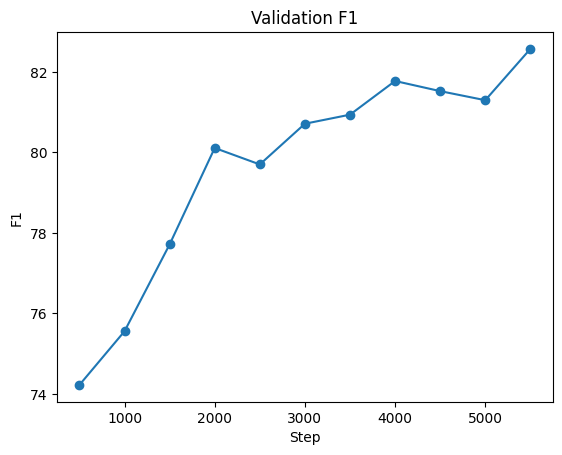

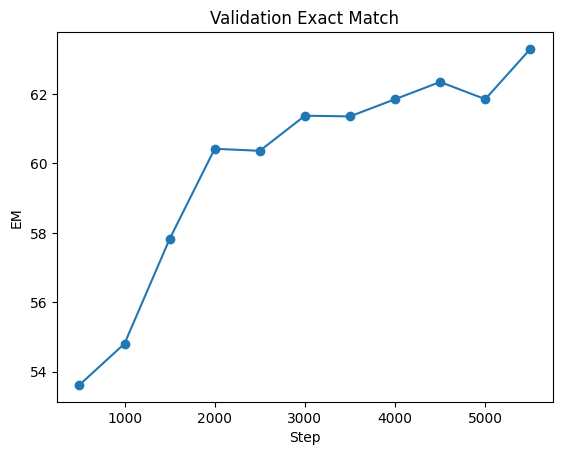

[{'epoch': 0.9442287327920932, 'grad_norm': 52.61648941040039, 'learning_rate': 1.5839216378397457e-05, 'loss': 1.5433102416992188, 'step': 5350}, {'epoch': 0.953053300388281, 'grad_norm': 17.181686401367188, 'learning_rate': 1.570684786445464e-05, 'loss': 1.525599365234375, 'step': 5400}, {'epoch': 0.9618778679844687, 'grad_norm': 40.21954345703125, 'learning_rate': 1.5574479350511826e-05, 'loss': 1.5613706970214845, 'step': 5450}, {'epoch': 0.9707024355806565, 'grad_norm': 30.081090927124023, 'learning_rate': 1.5442110836569007e-05, 'loss': 1.5538897705078125, 'step': 5500}, {'epoch': 0.9707024355806565, 'eval_exact_match': 63.304209690230344, 'eval_f1': 82.57269622932606, 'eval_loss': 1.4922330379486084, 'eval_runtime': 137.4089, 'eval_samples_per_second': 36.65, 'eval_steps_per_second': 4.585, 'step': 5500}]


In [ ]:
# Note: the checkpoint used here may not always appear in the logs,
# since some models were trained multiple times.
# I select the checkpoint with the best F1, while avoiding overfitting.

state = TrainerState.load_from_json(f"{OUTPUT_DIR_QA}/checkpoint-5500/trainer_state.json")
logs = state.log_history


steps, f1s, ems = [], [], []

for r in logs:
    if "eval_f1" in r:
        steps.append(r.get("step", r.get("global_step")))
        f1s.append(r["eval_f1"])
        ems.append(r["eval_exact_match"])

plt.figure()
plt.plot(steps, f1s, marker="o")
plt.xlabel("Step"); plt.ylabel("F1"); plt.title("Validation F1")
plt.savefig(f"{PLOTS_DIR_QA}/validation_F1_qa.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

plt.figure()
plt.plot(steps, ems, marker="o")
plt.xlabel("Step"); plt.ylabel("EM"); plt.title("Validation Exact Match")
plt.savefig(f"{PLOTS_DIR_QA}/validation_EM_qa.png",
            dpi=300,
            bbox_inches="tight")
plt.show()
print([k for k in logs[-5:]])

# Second Step. Cross-Task Transfer: Fine-tuning XLM-RoBERTa from English NLI to Russian Extractive QA

## 1. XLM-R Finetuned on English NLI

### Model Initialization

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=3
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Training

In [ ]:
#I use even more detailed logs here, as during training I had to do lots of troubleshooting

accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]}

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR_NLI,
    eval_strategy="steps",
    eval_steps=1000,
    learning_rate=2e-5,
    lr_scheduler_type='linear',
    warmup_ratio=0.1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    fp16=True,
    gradient_checkpointing=True,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=100,
    logging_first_step=True,
    log_level='info',
    save_steps=1000,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="wandb",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=xnli_en_tok["train"],
    eval_dataset=xnli_en_tok["validation"],
    compute_metrics=compute_metrics,
)

trainer.train()

PyTorch: setting up devices
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The following columns in the Training set don't have a corresponding argument in `XLMRobertaForSequenceClassification.forward` and have been ignored: hypothesis, premise. If hypothesis, premise are not expected by `XLMRobertaForSequenceClassification.forward`,  you can safely ignore this message.
***** Running training *****
  Num examples = 392,702
  Num Epochs = 2
  Instantaneous batch size per device = 8
  Total train batch size (w. parallel, distributed & accumulation) = 8
  Gradient Accumulation steps = 1
  Total optimization steps = 98,176
  Number of trainable parameters = 278,045,955


Step,Training Loss,Validation Loss,Accuracy
1000,1.103973,1.097136,0.333333
2000,0.935038,0.885916,0.612048
3000,0.855840,0.789077,0.672691
4000,0.780283,0.685402,0.722088
5000,0.708268,0.624997,0.762651
6000,0.702217,0.634701,0.745382
7000,0.677911,0.684686,0.741767
8000,0.652126,0.704246,0.720884
9000,0.685449,0.661689,0.728514
10000,0.646484,0.713354,0.750201


The following columns in the Evaluation set don't have a corresponding argument in `XLMRobertaForSequenceClassification.forward` and have been ignored: hypothesis, premise. If hypothesis, premise are not expected by `XLMRobertaForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 2490
  Batch size = 16
Saving model checkpoint to /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/nli_model/checkpoint-1000
Configuration saved in /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/nli_model/checkpoint-1000/config.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/nli_model/checkpoint-1000/model.safetensors
The following columns in the Evaluation set don't have a corresponding argument in `XLMRobertaForSequenceClassification.forward` and have been ignored: hypothesis, premise. If hypothesis, premise are not expected by `XLMRobertaForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 2490
  Batch size = 16
Saving model checkpoint to /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/nli_model/checkpoint-2000
Configuration saved in /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/nli_model/checkpoint-2000/config.json


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/nli_model/checkpoint-24000/model.safetensors
The following columns in the Evaluation set don't have a corresponding argument in `XLMRobertaForSequenceClassification.forward` and have been ignored: hypothesis, premise. If hypothesis, premise are not expected by `XLMRobertaForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 2490
  Batch size = 16
Saving model checkpoint to /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/nli_model/checkpoint-25000
Configuration saved in /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/nli_model/checkpoint-25000/config.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/nli_model/checkpoint-25000/model.safetensors


KeyboardInterrupt: 

### Training Curves: Accuracy, Loss, and Learning Rate

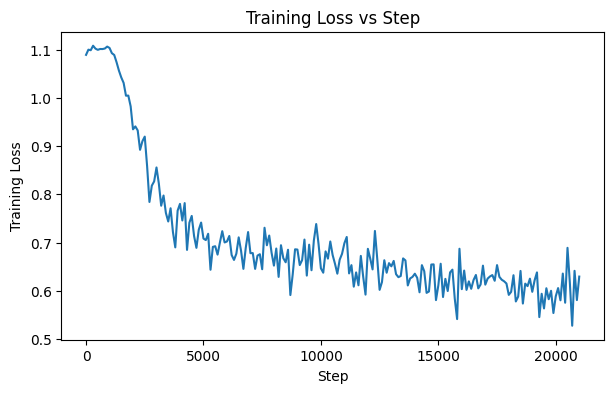

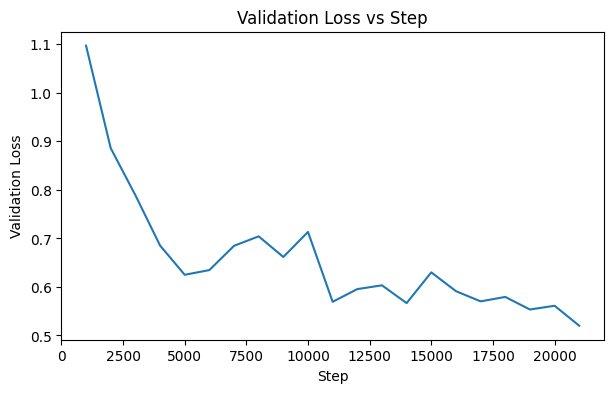

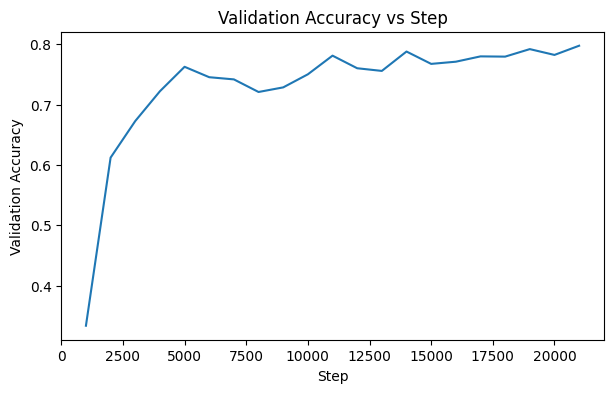

In [ ]:
OUT = OUTPUT_DIR_NLI

# load trainer_state.json
state_path = os.path.join(OUT, "checkpoint-21000", "trainer_state.json")

with open(state_path, "r", encoding="utf-8") as f:
    state = json.load(f)

df = pd.DataFrame(state["log_history"])
df = df[df["step"].notna()].copy()
df["step"] = df["step"].astype(int)

# ---------------------------
# 1. Training loss
# ---------------------------
train_df = df[df["loss"].notna()]

plt.figure(figsize=(7,4))
plt.plot(train_df["step"], train_df["loss"])
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Step")

plt.savefig(os.path.join(OUT, "train_loss.png"))
plt.show()


# ---------------------------
# 2. Validation loss
# ---------------------------
val_loss_df = df[df["eval_loss"].notna()]

plt.figure(figsize=(7,4))
plt.plot(val_loss_df["step"], val_loss_df["eval_loss"])
plt.xlabel("Step")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Step")

plt.savefig(os.path.join(OUT, "val_loss.png"))
plt.show()


# ---------------------------
# 3. Validation accuracy
# ---------------------------
val_acc_df = df[df["eval_accuracy"].notna()]

plt.figure(figsize=(7,4))
plt.plot(val_acc_df["step"], val_acc_df["eval_accuracy"])
plt.xlabel("Step")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Step")

plt.savefig(os.path.join(OUT, "val_accuracy.png"))
plt.show()

## 2. XLM-R Transfer: EN NLI → RU QA

### Pretrained Checkpoint Initialization

In [ ]:
NLI_CKPT = f"{OUTPUT_DIR_NLI}/checkpoint-21000"

tokenizer = AutoTokenizer.from_pretrained(NLI_CKPT)

config = AutoConfig.from_pretrained(NLI_CKPT)
config.num_labels = 2
ennli_ruqa_model = AutoModelForQuestionAnswering.from_pretrained(NLI_CKPT, config=config, ignore_mismatched_sizes=True)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForQuestionAnswering LOAD REPORT from: /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/nli_model/checkpoint-21000
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.bias      | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.dense.weight    | UNEXPECTED | 
qa_outputs.bias            | MISSING    | 
qa_outputs.weight          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
### Testing Before Training
print(model.config.num_labels)
print(model.qa_outputs.out_features)

2
2


### Training

### Defining Training Arguments

In [ ]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR_NLI_to_QA,
    eval_strategy="steps",
    eval_steps=500,

    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_strategy="steps",
    logging_steps=50,
    remove_unused_columns=True,
    report_to="wandb",
)


### Trainer + train/eval/predict

In [ ]:
trainer = Trainer(
    model=ennli_ruqa_model,
    args=training_args,
    train_dataset=qa_train,
    eval_dataset=qa_val_features,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train(resume_from_checkpoint=f"{OUTPUT_DIR_NLI_to_QA}/checkpoint-4500")

metrics = trainer.evaluate()
print(metrics)

pred_output = trainer.predict(qa_val_features)
pred_texts = postprocess_qa_predictions(qa["validation"], qa_val_features, pred_output.predictions)

trainer.save_model(OUTPUT_DIR_NLI_to_QA)
tokenizer.save_pretrained(OUTPUT_DIR_NLI_to_QA)

qa_val_features.save_to_disk(f"{PROJECT_DIR}/nli_to_qa_val_features")
qa_train.save_to_disk(f"{PROJECT_DIR}/nli_to_qa_train_features")


qa_train[0]["start_positions"]
qa_train[0]["end_positions"]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Step,Training Loss,Validation Loss,F1,Exact Match
5000,1.718020,1.518238,81.152615,61.914218
5500,1.558911,1.505991,81.913454,62.549643
6000,1.316364,1.536036,81.623690,62.112788


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Training Curves from Trainer Logs (F1 and EM). XLM-R Transfer: EN NLI → RU QA

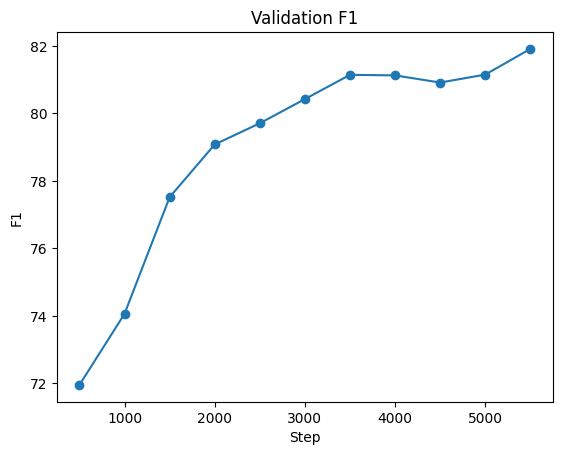

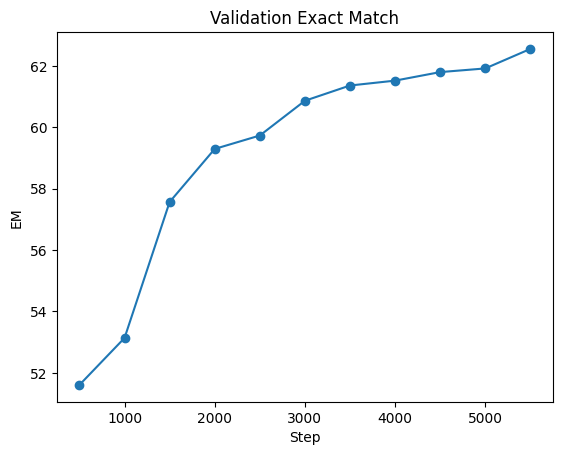

[{'epoch': 0.9442287327920932, 'grad_norm': 64.67815399169922, 'learning_rate': 1.0559477585598305e-05, 'loss': 1.5736933898925782, 'step': 5350}, {'epoch': 0.953053300388281, 'grad_norm': 36.02648162841797, 'learning_rate': 1.0471231909636428e-05, 'loss': 1.5729588317871093, 'step': 5400}, {'epoch': 0.9618778679844687, 'grad_norm': 35.599082946777344, 'learning_rate': 1.038298623367455e-05, 'loss': 1.5808088684082031, 'step': 5450}, {'epoch': 0.9707024355806565, 'grad_norm': 30.540592193603516, 'learning_rate': 1.0294740557712672e-05, 'loss': 1.5589109802246093, 'step': 5500}, {'epoch': 0.9707024355806565, 'eval_exact_match': 62.54964257347101, 'eval_f1': 81.91345398311033, 'eval_loss': 1.5059905052185059, 'eval_runtime': 136.5816, 'eval_samples_per_second': 36.872, 'eval_steps_per_second': 4.613, 'step': 5500}]


In [ ]:

state = TrainerState.load_from_json(f"{OUTPUT_DIR_NLI_to_QA}/checkpoint-5500/trainer_state.json")
logs = state.log_history


steps, f1s, ems = [], [], []

for r in logs:
    if "eval_f1" in r:
        steps.append(r.get("step", r.get("global_step")))
        f1s.append(r["eval_f1"])
        ems.append(r["eval_exact_match"])

plt.figure()
plt.plot(steps, f1s, marker="o")
plt.xlabel("Step"); plt.ylabel("F1"); plt.title("Validation F1")
plt.savefig(f"{PLOTS_DIR_NLI_to_QA}/validation_F1_NLI_to_QA.png",
            dpi=300,
            bbox_inches="tight")


plt.show()

plt.figure()
plt.plot(steps, ems, marker="o")
plt.xlabel("Step"); plt.ylabel("EM"); plt.title("Validation Exact Match")
plt.savefig(f"{PLOTS_DIR_QA}/validation_EM_qa.png",
            dpi=300,
            bbox_inches="tight")
plt.show()
print([k for k in logs[-5:]])

### Comparison: Baseline (XLM-R trained directly on extractive QA) vs XLM-R trained on EN NLI → RU QA

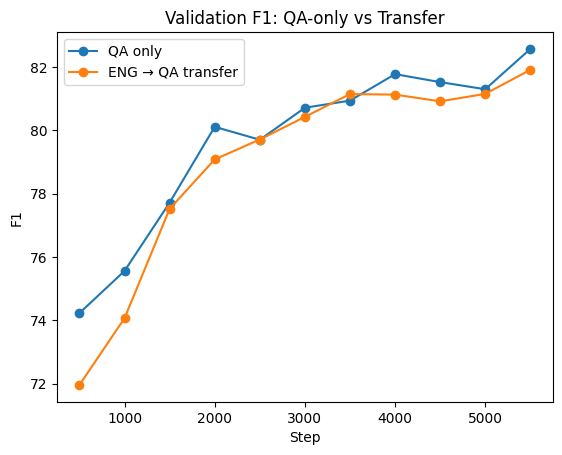

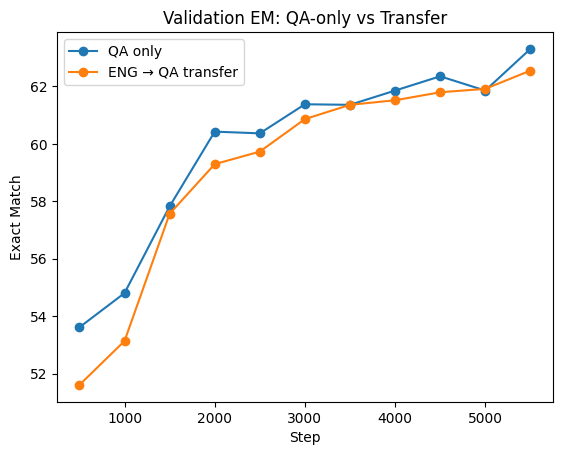

In [ ]:
#Here I just want to peek at the preliminary results, and notice that so far pretraining doesn't help for extractive QA in Russian
#The baseline is showing better results

s.makedirs(PLOTS_DIR_QA, exist_ok=True)

def extract_eval_curves(state_json_path):
    state = TrainerState.load_from_json(state_json_path)
    logs = state.log_history

    steps, f1s, ems = [], [], []
    for r in logs:
        if "eval_f1" in r:
            steps.append(r.get("step", r.get("global_step")))
            f1s.append(r["eval_f1"])
            ems.append(r.get("eval_exact_match", r.get("eval_em")))

    data = sorted(zip(steps, f1s, ems))
    steps, f1s, ems = zip(*data)
    return list(steps), list(f1s), list(ems)

# 1) QA-only run
qa_steps, qa_f1, qa_em = extract_eval_curves(
    f"{OUTPUT_DIR_QA}/checkpoint-5500/trainer_state.json"
)

# 2) ENG -> QA transfer run
transfer_steps, transfer_f1, transfer_em = extract_eval_curves(
    f"{OUTPUT_DIR_NLI_to_QA}/checkpoint-5500/trainer_state.json"
)


# ---- Plot F1 comparison ----
plt.figure()
plt.plot(qa_steps, qa_f1, marker="o", label="QA only")
plt.plot(transfer_steps, transfer_f1, marker="o", label="ENG → QA transfer")
plt.xlabel("Step")
plt.ylabel("F1")
plt.title("Validation F1: QA-only vs Transfer")
plt.legend()
plt.savefig(f"{PLOTS_DIR_QA}/compare_F1_QAonly_vs_transfer.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- Plot EM comparison ----
plt.figure()
plt.plot(qa_steps, qa_em, marker="o", label="QA only")
plt.plot(transfer_steps, transfer_em, marker="o", label="ENG → QA transfer")
plt.xlabel("Step")
plt.ylabel("Exact Match")
plt.title("Validation EM: QA-only vs Transfer")
plt.legend()
plt.savefig(f"{PLOTS_DIR_QA}/compare_EM_QAonly_vs_transfer.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
#Comparison: Baseline (XLM-R trained directly on extractive QA) vs XLM-R trained on EN NLI → RU QA (table format)
#here I just want to do a fine grained check, point-wise

import pandas as pd
from IPython.display import display

qa_only = pd.DataFrame({
    "step": [500,1000,1500,2000,2500,3000,3500,4000,4500,5000],
    "F1_QA_only": [74.22,75.56,77.72,80.11,79.70,80.71,80.94,81.78,81.52,81.30],
    "EM_QA_only": [53.61,54.81,57.82,60.42,60.37,61.38,61.36,61.85,62.35,61.85]
})

transfer = pd.DataFrame({
    "step": [500,1000,1500,2000,2500,3000,3500,4000,4500,5000],
    "F1_transfer": [73.666266,75.112639,78.344530,79.608432,80.180461,80.551219,80.858822,81.507965,81.092829,81.028906],
    "EM_transfer": [53.375695,53.991263,58.260524,59.829230,60.266084,60.524226,60.941223,61.834790,61.914218,61.636219]
})


comparison = qa_only.merge(transfer, on="step")


comparison["F1_diff"] = comparison["F1_transfer"] - comparison["F1_QA_only"]
comparison["EM_diff"] = comparison["EM_transfer"] - comparison["EM_QA_only"]

comparison = comparison.round(2)

display(comparison)

comparison.to_csv("qa_transfer_comparison.csv", index=False)

,step,F1_QA_only,EM_QA_only,F1_transfer,EM_transfer,F1_diff,EM_diff
0,500,74.22,53.61,73.67,53.38,-0.55,-0.23
1,1000,75.56,54.81,75.11,53.99,-0.45,-0.82
2,1500,77.72,57.82,78.34,58.26,0.62,0.44
3,2000,80.11,60.42,79.61,59.83,-0.50,-0.59
4,2500,79.70,60.37,80.18,60.27,0.48,-0.10
5,3000,80.71,61.38,80.55,60.52,-0.16,-0.86
6,3500,80.94,61.36,80.86,60.94,-0.08,-0.42
7,4000,81.78,61.85,81.51,61.83,-0.27,-0.02
8,4500,81.52,62.35,81.09,61.91,-0.43,-0.44
9,5000,81.30,61.85,81.03,61.64,-0.27,-0.21


# Third Step: Cross-Task Transfer. Fine-Tuning XLM-RoBERTa from Russian NLI to Russian Extractive QA



##1. XLMI Trained on RU NLI

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model_ru = AutoModelForSequenceClassification.from_pretrained("xlm-roberta-base", num_labels=3)


accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]}

args_ru = TrainingArguments(
    output_dir=OUTPUT_DIR_RU_NLI,
    eval_strategy="steps",
    eval_steps=1000,
    learning_rate=2e-5,
    lr_scheduler_type="linear",
    warmup_ratio=0.1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    fp16=True,
    gradient_checkpointing=True,
    num_train_epochs=1,
    weight_decay=0.01,
    logging_steps=100,
    logging_first_step=True,
    log_level="info",
    save_strategy="steps",
    save_steps=1000,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="wandb",
)


trainer_ru = Trainer(
    model=model_ru,
    args=args_ru,
    train_dataset=xnli_ru_tok["train"],
    eval_dataset=xnli_ru_tok["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)


p0 = trainer_ru.predict(xnli_ru_tok["validation"])
print("Pred dist BEFORE:", np.bincount(np.argmax(p0.predictions, axis=-1), minlength=3))

trainer_ru.train()

p1 = trainer_ru.predict(xnli_ru_tok["validation"])
print("Pred dist AFTER:", np.bincount(np.argmax(p1.predictions, axis=-1), minlength=3))

loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--xlm-roberta-base/snapshots/e73636d4f797dec63c3081bb6ed5c7b0bb3f2089/config.json
Model config XLMRobertaConfig {
  "add_cross_attention": false,
  "architectures": [
    "XLMRobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1,
    "LABEL_2": 2
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "xlm-roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_past": true,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": 

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
PyTorch: setting up devices
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instea

Pred dist BEFORE: [   0 2490    0]


The following columns in the Training set don't have a corresponding argument in `XLMRobertaForSequenceClassification.forward` and have been ignored: hypothesis, premise. If hypothesis, premise are not expected by `XLMRobertaForSequenceClassification.forward`,  you can safely ignore this message.
***** Running training *****
  Num examples = 392,702
  Num Epochs = 1
  Instantaneous batch size per device = 8
  Total train batch size (w. parallel, distributed & accumulation) = 8
  Gradient Accumulation steps = 1
  Total optimization steps = 49,088
  Number of trainable parameters = 278,045,955


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-49000/model.safetensors
Saving Trainer.data_collator.tokenizer by default as Trainer.processing_class is `None`
tokenizer config file saved in /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-49000/tokenizer_config.json
Saving model checkpoint to /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-49088
Configuration saved in /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-49088/config.json


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-49088/model.safetensors
Saving Trainer.data_collator.tokenizer by default as Trainer.processing_class is `None`
tokenizer config file saved in /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-49088/tokenizer_config.json


Training completed. Do not forget to share your model on huggingface.co/models =)


Loading best model from /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-40000 (score: 0.7586345381526104).
Could not locate the best model at /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-40000/pytorch_model.bin, if you are running a distributed training on multiple nodes, you should activate `--save_on_each_node`.
The following columns in the test set don't have a corresponding argument in `XLMRobertaForSequenceClassification.forward` and have b

Pred dist AFTER: [668 945 877]


In [ ]:
# Here I resume interrupted training (ran out of memory)

RU_NLI_CKPT = f"{OUTPUT_DIR_RU_NLI}/checkpoint-62000"

tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")

config = AutoConfig.from_pretrained(RU_NLI_CKPT)

model_ru = AutoModelForSequenceClassification.from_pretrained(RU_NLI_CKPT)


args_ru_continue = TrainingArguments(
    output_dir=OUTPUT_DIR_RU_NLI,

    # continue logging nicely
    logging_steps=100,
    eval_strategy="steps",
    eval_steps=5000,
    save_steps=5000,

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=2,   # ← increase total epochs

    fp16=True,
    gradient_checkpointing=True,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    report_to="wandb",  # or "none"
)

trainer_ru = Trainer(
    model=model_ru,
    args=args_ru_continue,
    train_dataset=xnli_ru_tok["train"],
    eval_dataset=xnli_ru_tok["validation"],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)

trainer_ru.train(resume_from_checkpoint=RU_NLI_CKPT)

loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--xlm-roberta-base/snapshots/e73636d4f797dec63c3081bb6ed5c7b0bb3f2089/config.json
Model config XLMRobertaConfig {
  "add_cross_attention": false,
  "architectures": [
    "XLMRobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "xlm-roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_past": true,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 250002
}

loading configuration file /content/drive/MyDrive/Colab Notebooks/CoLi_Pro

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

PyTorch: setting up devices
Loading model from /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-61000.
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', '

Step,Training Loss,Validation Loss,Accuracy
62000,0.552447,0.634261,0.754618
63000,0.570272,0.623897,0.754618
64000,0.533010,0.616279,0.759438
65000,0.546564,0.650912,0.742972
66000,0.564770,0.657129,0.745783
67000,0.577667,0.602774,0.762651
68000,0.561374,0.653414,0.748594
69000,0.593294,0.662328,0.733735
70000,0.568664,0.634806,0.751004


The following columns in the Evaluation set don't have a corresponding argument in `XLMRobertaForSequenceClassification.forward` and have been ignored: hypothesis, premise. If hypothesis, premise are not expected by `XLMRobertaForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 2490
  Batch size = 16
Saving model checkpoint to /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-62000
Configuration saved in /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-62000/config.json


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-69000/model.safetensors
Saving Trainer.data_collator.tokenizer by default as Trainer.processing_class is `None`
tokenizer config file saved in /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-69000/tokenizer_config.json
The following columns in the Evaluation set don't have a corresponding argument in `XLMRobertaForSequenceClassification.forward` and have been ignored: hypothesis, premise. If hypothesis, premise are not expected by `XLMRobertaForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 2490
  Batch size = 16
Saving model checkpoint to /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-70000
Configuration saved in /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-70000/config.j

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model weights saved in /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-70000/model.safetensors
Saving Trainer.data_collator.tokenizer by default as Trainer.processing_class is `None`
tokenizer config file saved in /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-70000/tokenizer_config.json


KeyboardInterrupt: 

In [ ]:
import gc, torch

torch.cuda.empty_cache()
gc.collect()

print("GPU cleared")

GPU cleared


### Training Curves: Accuracy, Loss, and Learning Rate

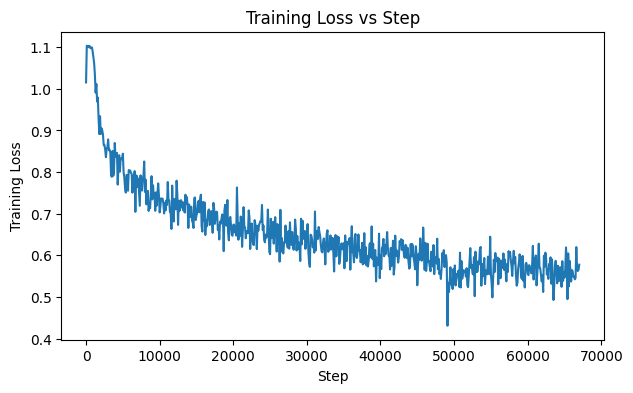

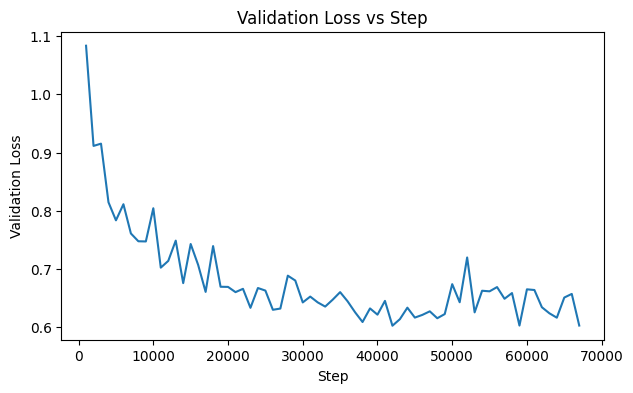

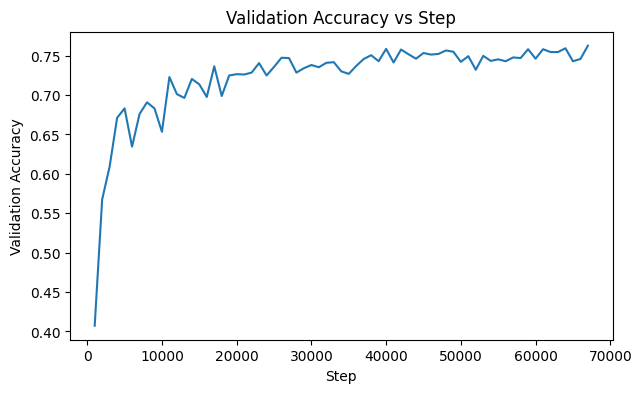

In [ ]:
OUT = OUTPUT_DIR_RU_NLI

state_path = os.path.join(OUT, "checkpoint-67000", "trainer_state.json")

with open(state_path, "r", encoding="utf-8") as f:
    state = json.load(f)

df = pd.DataFrame(state["log_history"])
df = df[df["step"].notna()].copy()
df["step"] = df["step"].astype(int)

# ---------------------------
# 1. Training loss
# ---------------------------
train_df = df[df["loss"].notna()]

plt.figure(figsize=(7,4))
plt.plot(train_df["step"], train_df["loss"])
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Step")

plt.savefig(os.path.join(OUT, "train_loss.png"))
plt.show()


# ---------------------------
# 2. Validation loss
# ---------------------------
val_loss_df = df[df["eval_loss"].notna()]

plt.figure(figsize=(7,4))
plt.plot(val_loss_df["step"], val_loss_df["eval_loss"])
plt.xlabel("Step")
plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Step")

plt.savefig(os.path.join(OUT, "val_loss.png"))
plt.show()


# ---------------------------
# 3. Validation accuracy
# ---------------------------
val_acc_df = df[df["eval_accuracy"].notna()]

plt.figure(figsize=(7,4))
plt.plot(val_acc_df["step"], val_acc_df["eval_accuracy"])
plt.xlabel("Step")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Step")

plt.savefig(os.path.join(OUT, "val_accuracy.png"))
plt.show()

RU state: /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-67000/trainer_state.json
RU best checkpoint: /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-67000
EN state: /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/nli_model/checkpoint-21000/trainer_state.json
EN best checkpoint: /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/nli_model/checkpoint-21000

ACCURACY
EN points: 21
RU points: 67
Using matched length: 21


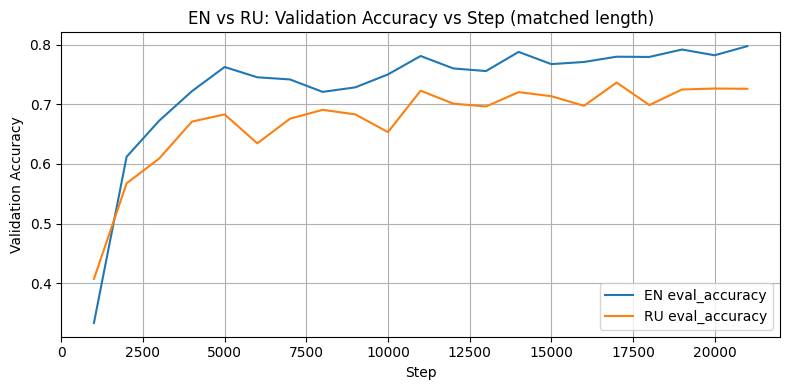

Saved: /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/compare_en_ru_eval_accuracy_vs_step_matched.png

LOSS
EN points: 21
RU points: 67
Using matched length: 21


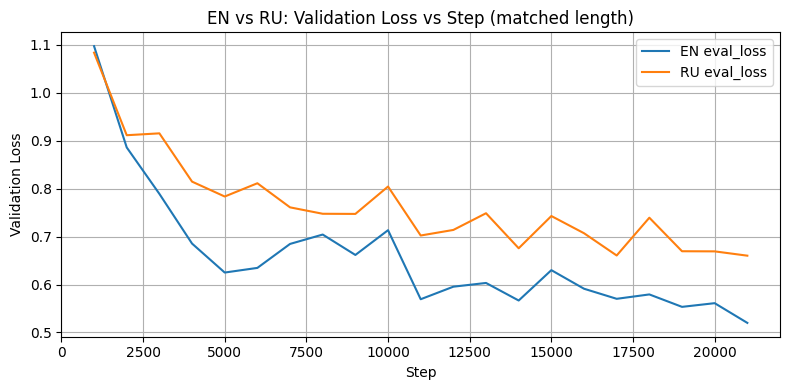

Saved: /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/compare_en_ru_eval_loss_vs_step_matched.png


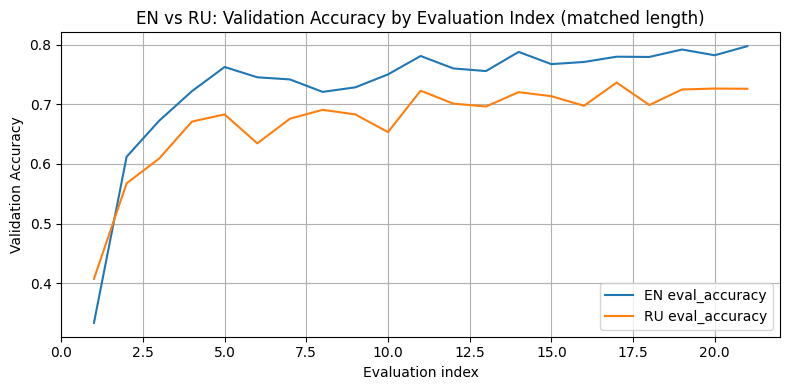

Saved: /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/compare_en_ru_eval_accuracy_by_eval_index_matched.png


In [ ]:
#Here I am comparing pretraining results btw En NLI vs Ru NLI
#English NLI shows better results. It is expected, because XNLI dataset is created from English.
#Russian NLI dataset - translated version from English NLI dataset.
#I sampled Russian translations - not the best quality, literal, don't convey idiomatic nuances.

OUT_RU = OUTPUT_DIR_RU_NLI
OUT_EN = OUTPUT_DIR_NLI

FORCE_RU_STATE = os.path.join(OUT_RU, "checkpoint-67000", "trainer_state.json")
FORCE_EN_STATE = None

def load_trainer_state(out_dir, forced_state_path=None):
    if forced_state_path is not None and os.path.exists(forced_state_path):
        state_path = forced_state_path
    else:
        ckpt_states = sorted(glob.glob(os.path.join(out_dir, "checkpoint-*", "trainer_state.json")))
        if not ckpt_states:
            raise FileNotFoundError(f"No trainer_state.json found under: {out_dir}")
        state_path = ckpt_states[-1]
    with open(state_path, "r", encoding="utf-8") as f:
        state = json.load(f)
    return state_path, state

def state_to_df(state):
    df = pd.DataFrame(state.get("log_history", []))
    df = df[df["step"].notna()].copy()
    df["step"] = df["step"].astype(int)
    df = df.sort_values("step")
    return df

def trim_to_same_length(df1, df2):
    min_len = min(len(df1), len(df2))
    df1_trim = df1.iloc[:min_len].copy()
    df2_trim = df2.iloc[:min_len].copy()
    return df1_trim, df2_trim, min_len

# ---- Load states ----
ru_state_path, ru_state = load_trainer_state(OUT_RU, FORCE_RU_STATE)
en_state_path, en_state = load_trainer_state(OUT_EN, FORCE_EN_STATE)

print("RU state:", ru_state_path)
print("RU best checkpoint:", ru_state.get("best_model_checkpoint"))
print("EN state:", en_state_path)
print("EN best checkpoint:", en_state.get("best_model_checkpoint"))

ru_df = state_to_df(ru_state)
en_df = state_to_df(en_state)

# ---- Extract metrics ----
ru_acc = ru_df.dropna(subset=["eval_accuracy"])[["step", "eval_accuracy"]].copy() if "eval_accuracy" in ru_df.columns else pd.DataFrame()
en_acc = en_df.dropna(subset=["eval_accuracy"])[["step", "eval_accuracy"]].copy() if "eval_accuracy" in en_df.columns else pd.DataFrame()

ru_loss = ru_df.dropna(subset=["eval_loss"])[["step", "eval_loss"]].copy() if "eval_loss" in ru_df.columns else pd.DataFrame()
en_loss = en_df.dropna(subset=["eval_loss"])[["step", "eval_loss"]].copy() if "eval_loss" in en_df.columns else pd.DataFrame()

# =========================================================
# 1) MATCHED ACCURACY VS STEP
# =========================================================
if not ru_acc.empty and not en_acc.empty:
    en_acc_m, ru_acc_m, n_acc = trim_to_same_length(en_acc, ru_acc)

    print("\nACCURACY")
    print("EN points:", len(en_acc))
    print("RU points:", len(ru_acc))
    print("Using matched length:", n_acc)

    plt.figure(figsize=(8, 4))
    plt.plot(en_acc_m["step"], en_acc_m["eval_accuracy"], label="EN eval_accuracy")
    plt.plot(ru_acc_m["step"], ru_acc_m["eval_accuracy"], label="RU eval_accuracy")
    plt.xlabel("Step")
    plt.ylabel("Validation Accuracy")
    plt.title("EN vs RU: Validation Accuracy vs Step (matched length)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    out_path = os.path.join(OUT_RU, "compare_en_ru_eval_accuracy_vs_step_matched.png")
    plt.savefig(out_path, dpi=200)
    plt.show()
    plt.close()
    print("Saved:", out_path)
else:
    print("Cannot plot matched accuracy vs step: missing eval_accuracy in one run.")

# =========================================================
# 2) MATCHED LOSS VS STEP
# =========================================================
if not ru_loss.empty and not en_loss.empty:
    en_loss_m, ru_loss_m, n_loss = trim_to_same_length(en_loss, ru_loss)

    print("\nLOSS")
    print("EN points:", len(en_loss))
    print("RU points:", len(ru_loss))
    print("Using matched length:", n_loss)

    plt.figure(figsize=(8, 4))
    plt.plot(en_loss_m["step"], en_loss_m["eval_loss"], label="EN eval_loss")
    plt.plot(ru_loss_m["step"], ru_loss_m["eval_loss"], label="RU eval_loss")
    plt.xlabel("Step")
    plt.ylabel("Validation Loss")
    plt.title("EN vs RU: Validation Loss vs Step (matched length)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    out_path = os.path.join(OUT_RU, "compare_en_ru_eval_loss_vs_step_matched.png")
    plt.savefig(out_path, dpi=200)
    plt.show()
    plt.close()
    print("Saved:", out_path)
else:
    print("Cannot plot matched loss vs step: missing eval_loss in one run.")

# =========================================================
# 3) MATCHED ACCURACY BY EVAL INDEX
# =========================================================
if not ru_acc.empty and not en_acc.empty:
    en_acc_i, ru_acc_i, n_idx = trim_to_same_length(en_acc, ru_acc)

    en_acc_i = en_acc_i.reset_index(drop=True)
    ru_acc_i = ru_acc_i.reset_index(drop=True)

    en_acc_i["eval_idx"] = range(1, n_idx + 1)
    ru_acc_i["eval_idx"] = range(1, n_idx + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(en_acc_i["eval_idx"], en_acc_i["eval_accuracy"], label="EN eval_accuracy")
    plt.plot(ru_acc_i["eval_idx"], ru_acc_i["eval_accuracy"], label="RU eval_accuracy")
    plt.xlabel("Evaluation index")
    plt.ylabel("Validation Accuracy")
    plt.title("EN vs RU: Validation Accuracy by Evaluation Index (matched length)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    out_path = os.path.join(OUT_RU, "compare_en_ru_eval_accuracy_by_eval_index_matched.png")
    plt.savefig(out_path, dpi=200)
    plt.show()
    plt.close()
    print("Saved:", out_path)
else:
    print("Cannot plot matched accuracy by eval index: missing eval_accuracy in one run.")

## 2. XLM-R Transfer: RU NLI → QA RU

### Pretrained Checkpoint Initialization

In [ ]:
RU_NLI_CKPT = f"{OUTPUT_DIR_RU_NLI}/checkpoint-67000"

tokenizer = AutoTokenizer.from_pretrained(RU_NLI_CKPT)

config = AutoConfig.from_pretrained(RU_NLI_CKPT)
config.num_labels = 2

model = AutoModelForQuestionAnswering.from_pretrained(
    RU_NLI_CKPT,
    config=config,
    ignore_mismatched_sizes=True
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForQuestionAnswering LOAD REPORT from: /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-67000
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.bias      | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
classifier.dense.weight    | UNEXPECTED | 
qa_outputs.bias            | MISSING    | 
qa_outputs.weight          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Training

In [ ]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR_RU_NLI_TO_QA,

    eval_strategy="steps",
    eval_steps=500,

    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_strategy="steps",
    logging_steps=50,

    remove_unused_columns=True,
    # report_to="wandb",
)

In [ ]:
squad_metric = evaluate.load("squad")

def postprocess_qa_predictions(examples, features, raw_predictions, n_best_size=20, max_answer_length=30):
    all_start_logits, all_end_logits = raw_predictions

    example_id_to_index = {ex_id: i for i, ex_id in enumerate(examples["id"])}
    features_per_example = collections.defaultdict(list)

    for i in range(len(features)):
        features_per_example[example_id_to_index[features[i]["example_id"]]].append(i)

    predictions = collections.OrderedDict()

    for example_index in range(len(examples)):
        context = examples[example_index]["context"]
        feature_indices = features_per_example[example_index]

        best_text = ""
        best_score = -1e9

        for fi in feature_indices:
            start_logits = all_start_logits[fi]
            end_logits = all_end_logits[fi]
            offsets = features[fi]["offset_mapping"]

            start_indexes = np.argsort(start_logits)[-n_best_size:][::-1]
            end_indexes = np.argsort(end_logits)[-n_best_size:][::-1]

            for s in start_indexes:
                for e in end_indexes:
                    if s >= len(offsets) or e >= len(offsets):
                        continue
                    if offsets[s] is None or offsets[e] is None:
                        continue
                    if e < s:
                        continue
                    if (e - s + 1) > max_answer_length:
                        continue

                    start_char = offsets[s][0]
                    end_char = offsets[e][1]
                    text = context[start_char:end_char]
                    score = start_logits[s] + end_logits[e]

                    if score > best_score:
                        best_score = score
                        best_text = text

        predictions[examples[example_index]["id"]] = best_text

    return predictions


def compute_metrics(p):
    try:
        preds = postprocess_qa_predictions(
            qa["validation"],
            qa_val_features,
            p.predictions
        )


        formatted_predictions = [{"id": str(k), "prediction_text": v} for k, v in preds.items()]
        references = [{"id": str(ex["id"]), "answers": ex["answers"]} for ex in qa["validation"]]

        result = squad_metric.compute(
            predictions=formatted_predictions,
            references=references
        )

        return {
            "f1": result["f1"],
            "exact_match": result["exact_match"]
        }

    except Exception as e:
        print("METRICS ERROR:", e)
        return {"f1": 0.0, "exact_match": 0.0}

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=qa_train,
    eval_dataset=qa_val_features,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

pred_output = trainer.predict(qa_val_features)
pred_texts = postprocess_qa_predictions(qa["validation"], qa_val_features, pred_output.predictions)


trainer.train()

metrics = trainer.evaluate()
print(metrics)

squad_metric = evaluate.load("squad")


trainer.save_model(OUTPUT_DIR_RU_NLI_TO_QA)
tokenizer.save_pretrained(OUTPUT_DIR_RU_NLI_TO_QA)


Step,Training Loss,Validation Loss,Model Preparation Time,F1,Exact Match
500,2.576407,2.209344,0.002600,71.985987,51.171565
1000,2.153152,1.895355,0.002600,74.876054,54.805401
1500,1.930640,1.782200,0.002600,77.869924,57.744241
2000,1.701572,1.751413,0.002600,78.925253,58.935663
2500,1.780539,1.681066,0.002600,79.334694,59.511517
3000,1.687637,1.630846,0.002600,79.653059,59.928515
3500,1.688999,1.579149,0.002600,80.441536,60.444797
4000,1.639713,1.583828,0.002600,80.595308,60.683082
4500,1.538921,1.572884,0.002600,80.241739,60.921366
5000,1.729321,1.566943,0.002600,79.950527,61.139793


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Trainer Log Plots (F1/EM)

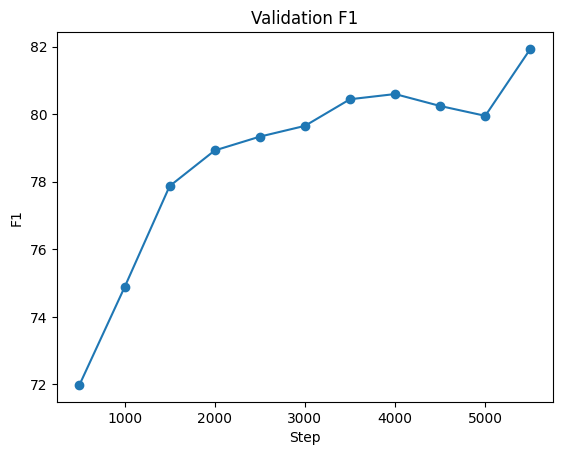

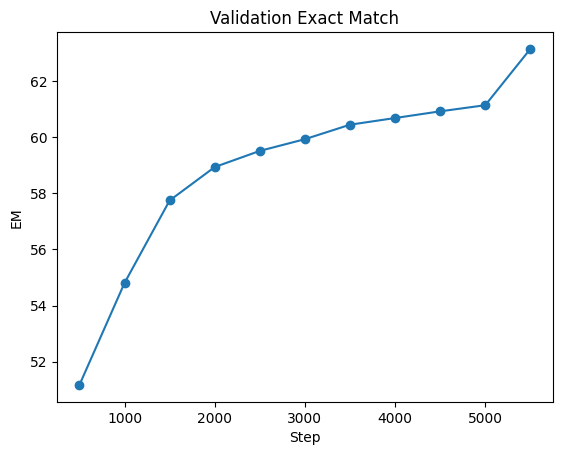

[{'epoch': 0.9442287327920932, 'grad_norm': 67.52235412597656, 'learning_rate': 1.0559477585598305e-05, 'loss': 1.5951617431640626, 'step': 5350}, {'epoch': 0.953053300388281, 'grad_norm': 44.447540283203125, 'learning_rate': 1.0471231909636428e-05, 'loss': 1.543288116455078, 'step': 5400}, {'epoch': 0.9618778679844687, 'grad_norm': 34.84457778930664, 'learning_rate': 1.038298623367455e-05, 'loss': 1.6090533447265625, 'step': 5450}, {'epoch': 0.9707024355806565, 'grad_norm': 31.77439308166504, 'learning_rate': 1.0294740557712672e-05, 'loss': 1.5649711608886718, 'step': 5500}, {'epoch': 0.9707024355806565, 'eval_exact_match': 63.145353455123114, 'eval_f1': 81.93088607479386, 'eval_loss': 1.5244457721710205, 'eval_model_preparation_time': 0.0026, 'eval_runtime': 135.1674, 'eval_samples_per_second': 37.257, 'eval_steps_per_second': 4.661, 'step': 5500}]


In [ ]:
state = TrainerState.load_from_json(f"{OUTPUT_DIR_RU_NLI_TO_QA}/checkpoint-5500/trainer_state.json")

logs = state.log_history


steps, f1s, ems = [], [], []

for r in logs:
    if "eval_f1" in r:
        steps.append(r.get("step", r.get("global_step")))
        f1s.append(r["eval_f1"])
        ems.append(r["eval_exact_match"])

plt.figure()
plt.plot(steps, f1s, marker="o")
plt.xlabel("Step"); plt.ylabel("F1"); plt.title("Validation F1")
plt.savefig(f"{OUTPUT_DIR_RU_NLI_TO_QA}/validation_F1_RuNLI_to_RuQA.png",
            dpi=300,
            bbox_inches="tight")


plt.show()

plt.figure()
plt.plot(steps, ems, marker="o")
plt.xlabel("Step"); plt.ylabel("EM"); plt.title("Validation Exact Match")
plt.savefig(f"{OUTPUT_DIR_RU_NLI_TO_QA}/validation_EM_RuNLI_to_RuQA.png",
            dpi=300,
            bbox_inches="tight")
plt.show()
print([k for k in logs[-5:]])

### Comparison: Baseline (XLM-R trained directly on extractive QA) vs XLM-R trained on EN NLI → RU QA vs XLM-R trained on RU NLI → RU QA

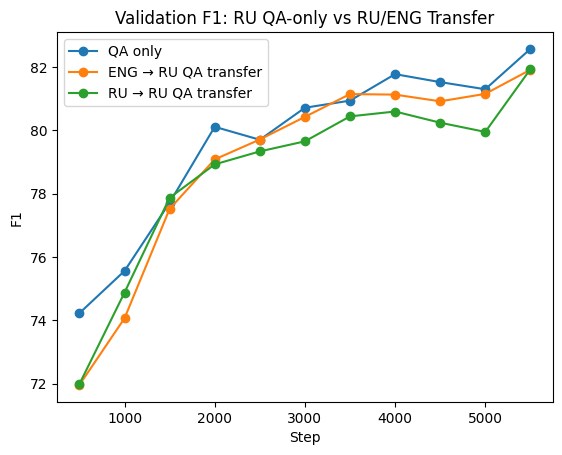

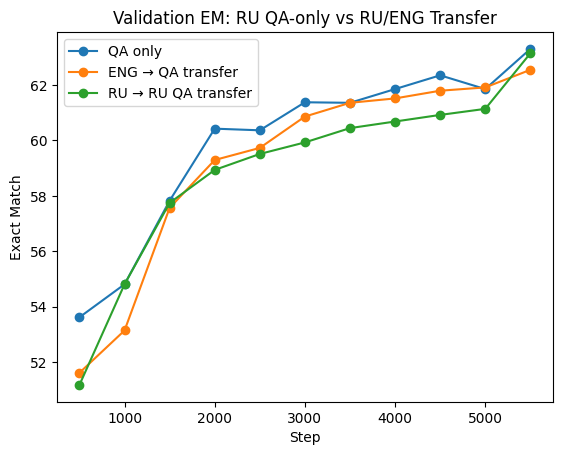

In [ ]:
def extract_eval_curves(state_json_path):
    state = TrainerState.load_from_json(state_json_path)
    logs = state.log_history

    steps, f1s, ems = [], [], []
    for r in logs:
        if "eval_f1" in r:
            steps.append(r.get("step", r.get("global_step")))
            f1s.append(r["eval_f1"])
            ems.append(r.get("eval_exact_match", r.get("eval_em")))

    # sort by step (safe)
    data = sorted(zip(steps, f1s, ems))
    steps, f1s, ems = zip(*data)
    return list(steps), list(f1s), list(ems)

# 1) QA-only run (checkpoint-6500)
qa_steps, qa_f1, qa_em = extract_eval_curves(
    f"{OUTPUT_DIR_QA}/checkpoint-5500/trainer_state.json"
)

# 2) ENG -> QA transfer run (use your best checkpoint, e.g. 5500)
transfer_steps, transfer_f1, transfer_em = extract_eval_curves(
    f"{OUTPUT_DIR_NLI_to_QA}/checkpoint-5500/trainer_state.json"
)

ru_transfer_steps, ru_transfer_f1, ru_transfer_em = extract_eval_curves(
    f"{OUTPUT_DIR_RU_NLI_TO_QA}/checkpoint-5500/trainer_state.json"
)

# ---- Plot F1 comparison ----
plt.figure()
plt.plot(qa_steps, qa_f1, marker="o", label="QA only")
plt.plot(transfer_steps, transfer_f1, marker="o", label="ENG → RU QA transfer")
plt.plot(ru_transfer_steps, ru_transfer_f1, marker="o", label="RU → RU QA transfer")

plt.xlabel("Step")
plt.ylabel("F1")
plt.title("Validation F1: RU QA-only vs RU/ENG Transfer")
plt.legend()
plt.savefig(f"{OUTPUT_DIR_RU_NLI_TO_QA}/compare_F1_QAonly_vs_transfer.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- Plot EM comparison ----
plt.figure()
plt.plot(qa_steps, qa_em, marker="o", label="QA only")
plt.plot(transfer_steps, transfer_em, marker="o", label="ENG → QA transfer")
plt.plot(ru_transfer_steps, ru_transfer_em, marker="o", label="RU → RU QA transfer")

plt.xlabel("Step")
plt.ylabel("Exact Match")
plt.title("Validation EM: RU QA-only vs RU/ENG Transfer")
plt.legend()
plt.savefig(f"{OUTPUT_DIR_RU_NLI_TO_QA}/compare_EM_QAonly_vs_transfer.png", dpi=300, bbox_inches="tight")
plt.show()

# Additional Baseline: Finetuning RuBERT on Ru QA

## QA Data Set Tokenization

In [ ]:
#Same tokenization principle I used and explained for the baseline.

MAX_LEN = 384

def tokenize_qa_train(batch):
    tokenized = tokenizer(
        batch["question"],
        batch["context"],
        truncation="only_second",
        padding="max_length",
        max_length=MAX_LEN,
        return_offsets_mapping=True
    )

    start_positions = []
    end_positions = []

    for i, offsets in enumerate(tokenized["offset_mapping"]):
        answer = batch["answers"][i]

        if len(answer["answer_start"]) == 0:
            start_positions.append(0)
            end_positions.append(0)
            continue

        start_char = answer["answer_start"][0]
        end_char = start_char + len(answer["text"][0])

        sequence_ids = tokenized.sequence_ids(i)

        context_start = sequence_ids.index(1)
        context_end = len(sequence_ids) - 1 - sequence_ids[::-1].index(1)
        start_token = 0
        end_token = 0

        if not (offsets[context_start][0] <= start_char and offsets[context_end][1] >= end_char):
            start_positions.append(0)
            end_positions.append(0)
            continue

        for idx in range(context_start, context_end + 1):
            if offsets[idx][0] <= start_char < offsets[idx][1]:
                start_token = idx
            if offsets[idx][0] < end_char <= offsets[idx][1]:
                end_token = idx
                break


        if start_token == 0 or end_token == 0 or start_token > end_token:
          start_positions.append(0)
          end_positions.append(0)
        else:
          start_positions.append(start_token)
          end_positions.append(end_token)

    tokenized["start_positions"] = start_positions
    tokenized["end_positions"] = end_positions

    tokenized.pop("offset_mapping")
    return tokenized


def tokenize_qa_eval(batch):
    tokenized = tokenizer(
        batch["question"],
        batch["context"],
        truncation="only_second",
        padding="max_length",
        max_length=MAX_LEN,
        return_offsets_mapping=True
    )


    tokenized["example_id"] = batch["id"]

    start_positions = []
    end_positions = []

    for i, offsets in enumerate(tokenized["offset_mapping"]):
        answer = batch["answers"][i]

        if len(answer["answer_start"]) == 0:
            start_positions.append(0)
            end_positions.append(0)
            continue

        start_char = answer["answer_start"][0]
        end_char = start_char + len(answer["text"][0])

        sequence_ids = tokenized.sequence_ids(i)

        context_start = sequence_ids.index(1)
        context_end = len(sequence_ids) - 1 - sequence_ids[::-1].index(1)

        start_token = 0
        end_token = 0

        if not (offsets[context_start][0] <= start_char and offsets[context_end][1] >= end_char):
            start_positions.append(0)
            end_positions.append(0)
            continue

        for idx in range(context_start, context_end + 1):
            if offsets[idx][0] <= start_char < offsets[idx][1]:
                start_token = idx
            if offsets[idx][0] < end_char <= offsets[idx][1]:
                end_token = idx
                break

        start_positions.append(start_token)
        end_positions.append(end_token)

    tokenized["start_positions"] = start_positions
    tokenized["end_positions"] = end_positions

    new_offsets = []
    for i, offsets in enumerate(tokenized["offset_mapping"]):
        seq_ids = tokenized.sequence_ids(i)
        new_offsets.append([o if s == 1 else None for o, s in zip(offsets, seq_ids)])
    tokenized["offset_mapping"] = new_offsets

    return tokenized


qa_train = qa["train"].map(tokenize_qa_train, batched=True, remove_columns=qa["train"].column_names)
qa_val_features = qa["validation"].map(tokenize_qa_eval, batched=True, remove_columns=qa["validation"].column_names)

Map:   0%|          | 0/45328 [00:00<?, ? examples/s]

Map:   0%|          | 0/5036 [00:00<?, ? examples/s]

In [ ]:
#Quick Check: We checked that for almost every question, at least one context window still contains the answer after splitting long texts.

has_answer_window = defaultdict(bool)

for ex_id, s, e in zip(
    qa_val_features["example_id"],
    qa_val_features["start_positions"],
    qa_val_features["end_positions"]
):
    if not (s == 0 and e == 0):
        has_answer_window[ex_id] = True

print(sum(has_answer_window.values()), "out of", len(qa["validation"]))
print(sum(has_answer_window.values()) / len(qa["validation"]) * 100)

from collections import defaultdict

has_answer_window = defaultdict(bool)

for ex_id, s, e in zip(
    qa_val_features["example_id"],
    qa_val_features["start_positions"],
    qa_val_features["end_positions"]
):
    if not (s == 0 and e == 0):
        has_answer_window[ex_id] = True

print(sum(has_answer_window.values()), "out of", len(qa["validation"]))
print(sum(has_answer_window.values()) / len(qa["validation"]) * 100)

4526 out of 5036
89.87291501191422


In [ ]:
print(max(len(x) for x in qa["train"]["context"]))

7231


In [ ]:
lengths = [len(tokenizer.tokenize(c)) for c in qa["train"]["context"]]
long_token_contexts = [c for c, l in zip(qa["train"]["context"], lengths) if l > 384]

print(f"{len(long_token_contexts) / len(qa['train']) * 100:.2f}% of train contexts are longer than 384 tokens")


1.43% of train contexts are longer than 384 tokens


## Model Initialization

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("DeepPavlov/rubert-base-cased")

model = AutoModelForQuestionAnswering.from_pretrained(
    "DeepPavlov/rubert-base-cased"
)

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
qa_outputs.bias                            | MISSING    | 
qa_outputs.weight                          

## Training

### Defining Training Arguments

In [ ]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR_RuBERT_QA,

    eval_strategy="steps",
    eval_steps=500,
    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,

    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_strategy="steps",
    logging_steps=50,

    remove_unused_columns=False,
    report_to="wandb",
)


### Postprocess + compute_metrics (EM/F1)

In [ ]:
squad_metric = evaluate.load("squad")

def postprocess_qa_predictions(examples, features, raw_predictions, n_best_size=20, max_answer_length=30):
    all_start_logits, all_end_logits = raw_predictions

    example_id_to_index = {ex_id: i for i, ex_id in enumerate(examples["id"])}
    features_per_example = collections.defaultdict(list)

    for i in range(len(features)):
        features_per_example[example_id_to_index[features[i]["example_id"]]].append(i)

    predictions = collections.OrderedDict()

    for example_index in range(len(examples)):
        context = examples[example_index]["context"]
        feature_indices = features_per_example[example_index]

        best_text = ""
        best_score = -1e9

        for fi in feature_indices:
            start_logits = all_start_logits[fi]
            end_logits = all_end_logits[fi]
            offsets = features[fi]["offset_mapping"]

            start_indexes = np.argsort(start_logits)[-n_best_size:][::-1]
            end_indexes = np.argsort(end_logits)[-n_best_size:][::-1]

            for s in start_indexes:
                for e in end_indexes:
                    if s >= len(offsets) or e >= len(offsets):
                        continue
                    if offsets[s] is None or offsets[e] is None:
                        continue
                    if e < s:
                        continue
                    if (e - s + 1) > max_answer_length:
                        continue

                    start_char = offsets[s][0]
                    end_char = offsets[e][1]
                    text = context[start_char:end_char]
                    score = start_logits[s] + end_logits[e]

                    if score > best_score:
                        best_score = score
                        best_text = text

        predictions[examples[example_index]["id"]] = best_text

    return predictions


def compute_metrics(p):
    try:
        preds = postprocess_qa_predictions(
            qa["validation"],
            qa_val_features,
            p.predictions
        )


        formatted_predictions = [{"id": str(k), "prediction_text": v} for k, v in preds.items()]
        references = [{"id": str(ex["id"]), "answers": ex["answers"]} for ex in qa["validation"]]

        result = squad_metric.compute(
            predictions=formatted_predictions,
            references=references
        )

        return {
            "f1": result["f1"],
            "exact_match": result["exact_match"]
        }

    except Exception as e:
        print("METRICS ERROR:", e)
        return {"f1": 0.0, "exact_match": 0.0}

### Trainer + train/eval/predict

In [ ]:
qa_val_features_for_trainer = qa_val_features.remove_columns(["offset_mapping", "example_id"])


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=qa_train,
    eval_dataset=qa_val_features_for_trainer,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

metrics = trainer.evaluate()
print(metrics)

pred_output = trainer.predict(qa_val_features_for_trainer)
pred_texts = postprocess_qa_predictions(qa["validation"], qa_val_features, pred_output.predictions)

trainer.save_model(OUTPUT_DIR_RuBERT_QA)
tokenizer.save_pretrained(OUTPUT_DIR_RuBERT_QA)

qa_val_features.save_to_disk(f"{OUTPUT_DIR_RuBERT_QA}/qa_val_features")

Step,Training Loss,Validation Loss,F1,Exact Match
500,1.113463,2.169704,72.252654,51.092137
1000,1.880883,1.666120,78.352736,57.426529
1500,1.774313,1.627073,80.303111,60.742653
2000,1.477411,1.697370,81.233084,61.715647
2500,1.570742,1.599633,80.275578,60.980937
3000,1.563723,1.555054,81.889529,62.450357
3500,1.562100,1.489769,82.234000,62.668785
4000,1.517485,1.510850,82.920249,63.979349
4500,1.482304,1.467436,82.185493,62.966640
5000,1.606134,1.484248,81.607741,62.152502


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
print(len(set(len(x) for x in qa_train["input_ids"])))

1


In [ ]:
###Here  I am just comparing two baselines: XLM-R trained directly on extractive Ru QA and RuBert trained directly on extractive Ru QA
# As expected, RuBert is showing higher performance compared to multilingual Roberta Model

xlm_qa_only = pd.DataFrame({
    "step": [500,1000,1500,2000,2500,3000,3500,4000,4500,5000],
    "F1_XLM_QA_only": [74.22,75.56,77.72,80.11,79.70,80.71,80.94,81.78,81.52,81.30],
    "EM_XLM_QA_only": [53.61,54.81,57.82,60.42,60.37,61.38,61.36,61.85,62.35,61.85]
})


rubert_qa_only = pd.DataFrame({
    "step": [500,1000,1500,2000,2500,3000,3500,4000,4500,5000],
    "F1_ruBert_QA_only": [72.252654, 78.352736, 80.303111, 81.233084, 80.275578, 81.889529, 82.234000, 82.920249, 82.185493, 83.461793],
    "EM_ruBert_QA_only": [51.092137, 57.426529, 60.742653, 61.715647, 60.980937, 62.450357, 62.668785, 63.979349, 62.966640, 64.47577]
})


comparison = xlm_qa_only.merge(rubert_qa_only, on="step")


comparison = comparison.round(2)

display(comparison)

comparison.to_csv("xlm_vs_rubert_qa_only_comparison.csv", index=False)

comparison.to_csv(
    os.path.join(OUTPUT_DIR_RuBERT_QA, "xlm_vs_rubert_qa_only_comparison.csv"),
    index=False
)

,step,F1_XLM_QA_only,EM_XLM_QA_only,F1_ruBert_QA_only,EM_ruBert_QA_only
0,500,74.22,53.61,72.25,51.09
1,1000,75.56,54.81,78.35,57.43
2,1500,77.72,57.82,80.30,60.74
3,2000,80.11,60.42,81.23,61.72
4,2500,79.70,60.37,80.28,60.98
5,3000,80.71,61.38,81.89,62.45
6,3500,80.94,61.36,82.23,62.67
7,4000,81.78,61.85,82.92,63.98
8,4500,81.52,62.35,82.19,62.97
9,5000,81.30,61.85,83.46,64.48


### Comparison: XLM-R -> RU QA only, XLM-R ENG -> RU QA transfer, XLM-R RU -> RU QA transfer, Rubert -> RU QA transfer

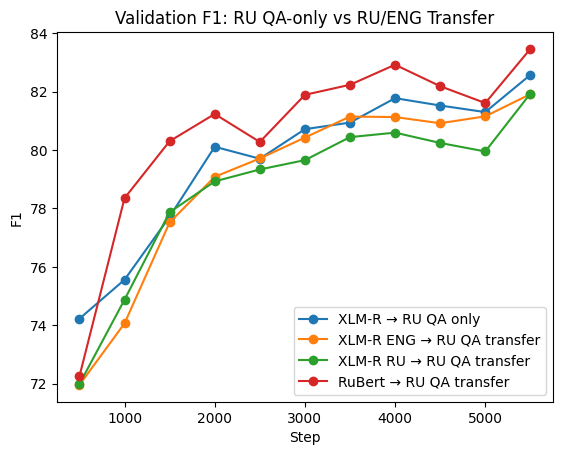

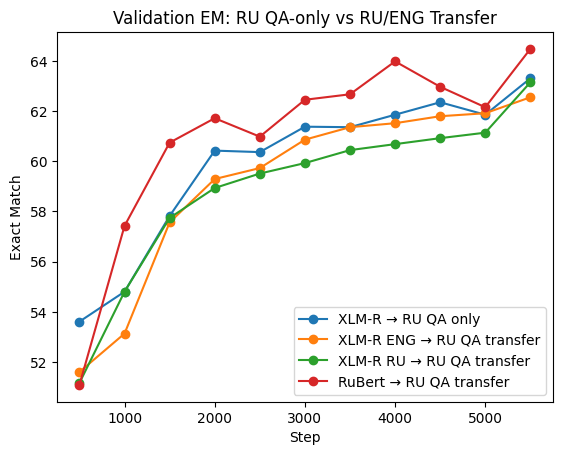

In [ ]:
def extract_eval_curves(state_json_path):
    state = TrainerState.load_from_json(state_json_path)
    logs = state.log_history

    steps, f1s, ems = [], [], []
    for r in logs:
        if "eval_f1" in r:
            steps.append(r.get("step", r.get("global_step")))
            f1s.append(r["eval_f1"])
            ems.append(r.get("eval_exact_match", r.get("eval_em")))

    data = sorted(zip(steps, f1s, ems))
    steps, f1s, ems = zip(*data)
    return list(steps), list(f1s), list(ems)

# 1) XLM-R RU QA-only run
qa_steps, qa_f1, qa_em = extract_eval_curves(
    f"{OUTPUT_DIR_QA}/checkpoint-5500/trainer_state.json"
)

# 2) XLM-R ENG -> RU QA transfer run
transfer_steps, transfer_f1, transfer_em = extract_eval_curves(
    f"{OUTPUT_DIR_NLI_to_QA}/checkpoint-5500/trainer_state.json"
)

# 3) XLM-R RU -> RU QA transfer run

ru_transfer_steps, ru_transfer_f1, ru_transfer_em = extract_eval_curves(
    f"{OUTPUT_DIR_RU_NLI_TO_QA}/checkpoint-5500/trainer_state.json"
)

# 4) RuBert -> RU QA-only run
rbrt_transfer_steps, rbrt_transfer_f1, rbrt_transfer_em = extract_eval_curves(
    f"{OUTPUT_DIR_RuBERT_QA}/checkpoint-5500/trainer_state.json"
)

# ---- Plot F1 comparison ----
plt.figure()
plt.plot(qa_steps, qa_f1, marker="o", label="XLM-R → RU QA only")
plt.plot(transfer_steps, transfer_f1, marker="o", label="XLM-R ENG → RU QA transfer")
plt.plot(ru_transfer_steps, ru_transfer_f1, marker="o", label="XLM-R RU → RU QA transfer")
plt.plot(rbrt_transfer_steps, rbrt_transfer_f1, marker="o", label="RuBert → RU QA transfer")

plt.xlabel("Step")
plt.ylabel("F1")
plt.title("Validation F1: RU QA-only vs RU/ENG Transfer")
plt.legend()
plt.savefig(f"{OUTPUT_DIR_RU_NLI_TO_QA}/compare_F1_QAonly_vs_transfer.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- Plot EM comparison ----
plt.figure()
plt.plot(qa_steps, qa_em, marker="o", label="XLM-R → RU QA only")
plt.plot(transfer_steps, transfer_em, marker="o", label="XLM-R ENG → RU QA transfer")
plt.plot(ru_transfer_steps, ru_transfer_em, marker="o", label="XLM-R RU → RU QA transfer")
plt.plot(rbrt_transfer_steps, rbrt_transfer_em, marker="o", label="RuBert → RU QA transfer")


plt.xlabel("Step")
plt.ylabel("Exact Match")
plt.title("Validation EM: RU QA-only vs RU/ENG Transfer")
plt.legend()
plt.savefig(f"{OUTPUT_DIR_RU_NLI_TO_QA}/compare_EM_QAonly_vs_transfer.png", dpi=300, bbox_inches="tight")
plt.show()

# Fourth Step: General Question Answering. XLM-R finetuned on Ru NLI -> trained on Eng General QA dataset

## 1. Baseline XLM-R → English QA only

In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
boolq_en = load_dataset("google/boolq")
print(boolq_en)

boolq_tokenizer = AutoTokenizer.from_pretrained("xlm-roberta-base")


def preprocess_function(examples):
    tokenized = boolq_tokenizer(
        examples["question"],
        examples["passage"],
        truncation=True,
        padding="max_length",
        max_length=256
    )
    tokenized["label"] = [int(x) for x in examples["answer"]]
    return tokenized

boolq_en_tokenized = boolq_en.map(preprocess_function, batched=True)

print(boolq_en_tokenized["train"][0])

DatasetDict({
    train: Dataset({
        features: ['question', 'answer', 'passage'],
        num_rows: 9427
    })
    validation: Dataset({
        features: ['question', 'answer', 'passage'],
        num_rows: 3270
    })
})


Map:   0%|          | 0/3270 [00:00<?, ? examples/s]

{'question': 'do iran and afghanistan speak the same language', 'answer': True, 'passage': 'Persian (/ˈpɜːrʒən, -ʃən/), also known by its endonym Farsi (فارسی fārsi (fɒːɾˈsiː) ( listen)), is one of the Western Iranian languages within the Indo-Iranian branch of the Indo-European language family. It is primarily spoken in Iran, Afghanistan (officially known as Dari since 1958), and Tajikistan (officially known as Tajiki since the Soviet era), and some other regions which historically were Persianate societies and considered part of Greater Iran. It is written in the Persian alphabet, a modified variant of the Arabic script, which itself evolved from the Aramaic alphabet.', 'input_ids': [0, 54, 193, 66, 136, 261, 80225, 35099, 70424, 70, 5701, 46876, 2, 57309, 66, 15, 64, 160548, 254, 248070, 233844, 42, 245857, 7879, 4, 20, 245313, 7879, 64, 247, 2843, 51529, 390, 6863, 3564, 45757, 7325, 172, 15, 59856, 14675, 1238, 47205, 14, 15, 420, 247085, 233844, 245761, 160548, 172, 233844, 16, 1

## Exploring General QA dataset in English. Removing unused columns

In [ ]:
boolq_en_tokenized = boolq_en_tokenized.remove_columns(
    ["question", "passage", "answer"]
)

boolq_en_tokenized.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

print(boolq_en_tokenized["train"].column_names)

['input_ids', 'attention_mask', 'label']


In [ ]:
boolq_en_tokenized = boolq_en_tokenized.rename_column("label", "labels")

In [ ]:
print(boolq_en_tokenized["train"].column_names)

['input_ids', 'attention_mask', 'labels']


## Model Initialization

In [ ]:
boolq_model = AutoModelForSequenceClassification.from_pretrained(
    "xlm-roberta-base",
    num_labels=2
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Training

In [ ]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR_BOOLQA_baseline,
    eval_strategy="steps",
    eval_steps=500,

    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_strategy="steps",
    logging_steps=50,

    remove_unused_columns=False,
    report_to="wandb",
)

In [ ]:
from collections import Counter
print(Counter(boolq_en["train"]["answer"]))

Counter({True: 5874, False: 3553})


In [ ]:
trainer = Trainer(
    model=boolq_model,
    args=training_args,
    train_dataset=boolq_en_tokenized["train"],
    eval_dataset=boolq_en_tokenized["validation"],
    compute_metrics=compute_metrics,
)

trainer.train()

metrics = trainer.evaluate()
print(metrics)

pred_output = trainer.predict(boolq_en_tokenized["validation"])
print(pred_output.metrics)

boolq_model.save_pretrained(OUTPUT_DIR_BOOLQA_baseline)
boolq_tokenizer.save_pretrained(OUTPUT_DIR_BOOLQA_baseline)


Step,Training Loss,Validation Loss,Accuracy,F1
500,0.663329,0.662240,0.621713,0.766736
1000,0.638044,0.648678,0.625994,0.767446
1500,0.639336,0.635318,0.654434,0.740469
2000,0.604748,0.659496,0.664220,0.775735
2500,0.580135,0.610626,0.677064,0.746763
3000,0.545877,0.601742,0.688991,0.763103
3500,0.531655,0.593124,0.691131,0.744949
4000,0.474011,0.651796,0.703976,0.786313
4500,0.451868,0.638661,0.716208,0.780095


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

{'eval_loss': 0.6514723300933838, 'eval_accuracy': 0.7036697247706422, 'eval_f1': 0.7859509609012592, 'eval_runtime': 51.0734, 'eval_samples_per_second': 64.026, 'eval_steps_per_second': 4.014, 'epoch': 4.0}
{'test_loss': 0.6514723300933838, 'test_accuracy': 0.7036697247706422, 'test_f1': 0.7859509609012592, 'test_runtime': 47.1877, 'test_samples_per_second': 69.298, 'test_steps_per_second': 4.344}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/xlm_boolqa_model/xlmr_en_boolqa_baseline/tokenizer_config.json',
 '/content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/xlm_boolqa_model/xlmr_en_boolqa_baseline/tokenizer.json')

In [ ]:
pred_output = trainer.predict(boolq_en_tokenized["validation"])
preds = np.argmax(pred_output.predictions, axis=-1)

import numpy as np
print("Predicted:", np.bincount(preds))
print("Gold:", np.bincount(boolq_en_tokenized["validation"]["labels"]))

Predicted: [ 776 2494]
Gold: [1237 2033]


## 2. XLM-R Transfer: RU NLI → general QA Boolq_en

In [ ]:
RU_NLI_CKPT = f"{OUTPUT_DIR_RU_NLI}/checkpoint-67000"

ru_boolq_tokenizer = AutoTokenizer.from_pretrained(RU_NLI_CKPT)

ru_boolq_model = AutoModelForSequenceClassification.from_pretrained(
    RU_NLI_CKPT,
    num_labels=2,
    ignore_mismatched_sizes=True
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds)
    }

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/ru_nli_model/checkpoint-67000
Key                        | Status   |                                                                                     
---------------------------+----------+-------------------------------------------------------------------------------------
classifier.out_proj.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([3, 768]) vs model:torch.Size([2, 768])
classifier.out_proj.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([3]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR_RU_NLI_TO_ENBOOLQA,

    eval_strategy="steps",
    eval_steps=500,

    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_strategy="steps",
    logging_steps=50,

    remove_unused_columns=False,
)

trainer = Trainer(
    model=ru_boolq_model,
    args=training_args,
    train_dataset=boolq_en_tokenized["train"],
    eval_dataset=boolq_en_tokenized["validation"],
    compute_metrics=compute_metrics,
)

trainer.train()

metrics = trainer.evaluate()
print(metrics)

pred_output = trainer.predict(boolq_en_tokenized["validation"])
print(pred_output.metrics)

ru_boolq_model.save_pretrained(OUTPUT_DIR_RU_NLI_TO_ENBOOLQA)
ru_boolq_tokenizer.save_pretrained(OUTPUT_DIR_RU_NLI_TO_ENBOOLQA)

Step,Training Loss,Validation Loss,Accuracy,F1
500,0.609508,0.567168,0.708257,0.788470
1000,0.522529,0.564694,0.741590,0.807210
1500,0.475116,0.551828,0.748930,0.800486
2000,0.538614,0.524565,0.752294,0.807235
2500,0.347388,0.729405,0.765443,0.820080


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Comparison: XLM-R -> general EN QA only, XLM-R RU ->  general QA EN transfer

Using length: 4


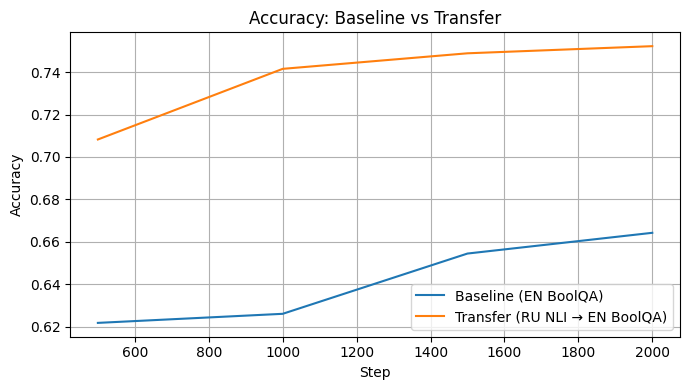

Saved: /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/compare_boolqa_accuracy.png


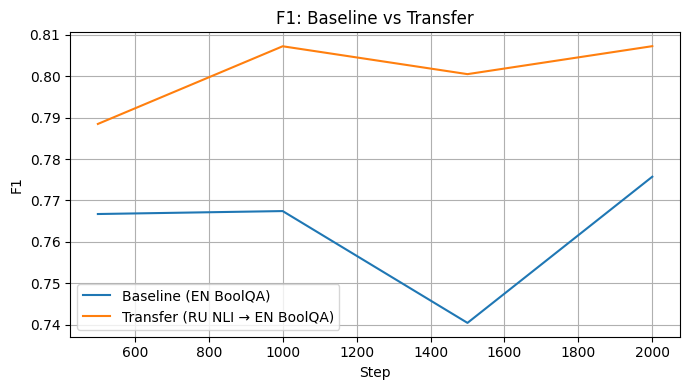

Saved: /content/drive/MyDrive/Colab Notebooks/CoLi_Project_MaiorovaLiliia/compare_boolqa_f1.png


In [ ]:
def extract_eval_curves_classification(state_json_path):
    state = TrainerState.load_from_json(state_json_path)
    logs = state.log_history

    steps, accs, f1s = [], [], []
    for r in logs:
        if "eval_f1" in r or "eval_accuracy" in r:
            step = r.get("step", r.get("global_step"))
            acc = r.get("eval_accuracy")
            f1 = r.get("eval_f1")

            if step is not None and acc is not None and f1 is not None:
                steps.append(step)
                accs.append(acc)
                f1s.append(f1)

    data = sorted(zip(steps, accs, f1s))
    steps, accs, f1s = zip(*data)
    return list(steps), list(accs), list(f1s)

# 1) XLM-R trained directly on En QA (yes/no)
direct_steps, direct_acc, direct_f1 = extract_eval_curves_classification(
    f"{OUTPUT_DIR_BOOLQA_baseline}/checkpoint-4000/trainer_state.json"
)

# 2) XLM-R first fine-tuned on Ru NLI, then trained on En QA (yes/no)
transfer_steps, transfer_acc, transfer_f1 = extract_eval_curves_classification(
    f"{OUTPUT_DIR_RU_NLI_TO_ENBOOLQA}/checkpoint-2000/trainer_state.json"
)

# ---- Matching lengths ----
min_len = min(len(direct_steps), len(transfer_steps))

direct_steps = direct_steps[:min_len]
direct_acc   = direct_acc[:min_len]
direct_f1    = direct_f1[:min_len]

transfer_steps = transfer_steps[:min_len]
transfer_acc   = transfer_acc[:min_len]
transfer_f1    = transfer_f1[:min_len]

print("Using length:", min_len)

# ---- Plot ACCURACY ----
plt.figure(figsize=(7, 4))
plt.plot(direct_steps, direct_acc, label="Baseline (EN BoolQA)")
plt.plot(transfer_steps, transfer_acc, label="Transfer (RU NLI → EN BoolQA)")
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.title("Accuracy: Baseline vs Transfer")
plt.grid(True)
plt.legend()
plt.tight_layout()

acc_path = os.path.join(PROJECT_DIR, "compare_boolqa_accuracy.png")
plt.savefig(acc_path, dpi=200)
plt.show()
plt.close()

print("Saved:", acc_path)

# ---- Plot F1 ----
plt.figure(figsize=(7, 4))
plt.plot(direct_steps, direct_f1, label="Baseline (EN BoolQA)")
plt.plot(transfer_steps, transfer_f1, label="Transfer (RU NLI → EN BoolQA)")
plt.xlabel("Step")
plt.ylabel("F1")
plt.title("F1: Baseline vs Transfer")
plt.grid(True)
plt.legend()
plt.tight_layout()

f1_path = os.path.join(PROJECT_DIR, "compare_boolqa_f1.png")
plt.savefig(f1_path, dpi=200)
plt.show()
plt.close()

print("Saved:", f1_path)